In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import model_from_json

In [17]:
# Check the number of images in both datasets
covid_path = r"C:\Users\ayush\Desktop\Detecting COVID-19 From Chest X-Ray\Dataset\COVID-19_Radiography_Dataset\COVID\images"
normal_path = r"C:\Users\ayush\Desktop\Detecting COVID-19 From Chest X-Ray\Dataset\COVID-19_Radiography_Dataset\Normal\images"
covid_Url = os.listdir(covid_path)
normal_Url = os.listdir(normal_path)

In [19]:
print(f"COVID images: {len(covid_Url)}")
print(f"Normal images: {len(normal_Url)}")

COVID images: 3616
Normal images: 10192


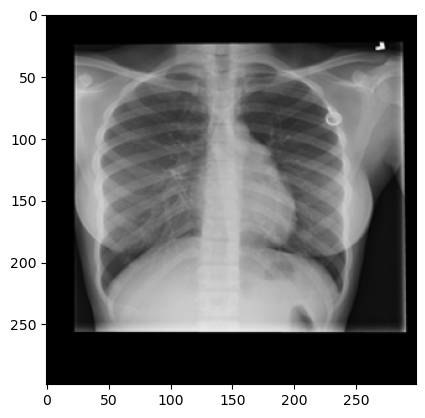

In [95]:
img = cv2.imread(r"C:\Users\ayush\Desktop\Detecting COVID-19 From Chest X-Ray\Dataset\COVID-19_Radiography_Dataset\Normal\images\Normal-1.png")
plt.imshow(img)

In [21]:
# Load and preprocess images
def loadImages(path, urls, target):
    images = []
    labels = []
    for i in range(len(urls)):
        img_path = os.path.join(path, urls[i])
        img = cv2.imread(img_path)
        img = cv2.resize(img, (100, 100))  # Resize image to match model input
        img = img / 255.0  # Normalize image
        images.append(img)
        labels.append(target)
    return images, labels

In [25]:
# Load COVID and Normal images
covidImages, covidTargets = loadImages(covid_path, covid_Url, 1)
normalImages, normalTargets = loadImages(normal_path, normal_Url, 0)

In [27]:
# Convert images and labels to numpy arrays
covidImages = np.asarray(covidImages)
normalImages = np.asarray(normalImages)

In [29]:
print(f"COVID Images Shape: {covidImages.shape}")
print(f"Normal Images Shape: {normalImages.shape}")

COVID Images Shape: (3616, 100, 100, 3)
Normal Images Shape: (10192, 100, 100, 3)


In [31]:
# Combine the data
data = np.r_[covidImages, normalImages]
targets = np.r_[covidTargets, normalTargets]

In [33]:
# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(data, targets, test_size=0.25)


In [35]:
# Check the shape of the train and test sets
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (10356, 100, 100, 3)
x_test shape: (3452, 100, 100, 3)


In [37]:
# Build the CNN Model
model = Sequential()

# Convolutional Layer 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional Layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output for Dense layer input
model.add(Flatten())

# Dense Layer 1
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Regularization with dropout

# Output Layer
model.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

C:\Users\ayush\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,801 (6.61 MB)

 Trainable params: 1,732,353 (6.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [39]:
# Train the model
history = model.fit(x_train, y_train, batch_size=32, epochs=10, validation_data=(x_test, y_test))


Epoch 1/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 176s 524ms/step - accuracy: 0.7801 - loss: 0.7493 - val_accuracy: 0.6886 - val_loss: 0.6584
Epoch 2/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 164s 507ms/step - accuracy: 0.8686 - loss: 0.3100 - val_accuracy: 0.8187 - val_loss: 0.3809
Epoch 3/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 162s 501ms/step - accuracy: 0.9011 - loss: 0.2375 - val_accuracy: 0.8331 - val_loss: 0.4418
Epoch 4/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 165s 510ms/step - accuracy: 0.9099 - loss: 0.2264 - val_accuracy: 0.8725 - val_loss: 0.3741
Epoch 5/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 166s 511ms/step - accuracy: 0.9283 - loss: 0.1745 - val_accuracy: 0.8824 - val_loss: 0.3816
Epoch 6/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 164s 505ms/step - accuracy: 0.9402 - loss: 0.1483 - val_accuracy: 0.8670 - val_loss: 0.4567
Epoch 7/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 169s 521ms/step - accuracy: 0.9451 - loss: 0.1546 - val_accuracy: 0.9119 - val_loss: 0.2155
Epoch 8/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 166s 511ms/step - accuracy: 0.9530 -

In [41]:
# Save the model architecture and weights
model.save_weights('model_weights.weights.h5')
model_json = model.to_json()

# Save model architecture as a JSON file
with open("model_architecture.json", "w") as json_file:
    json_file.write(model_json)

print("Model architecture and weights saved successfully.")

# Check if model files exist
if os.path.exists('model_architecture.json') and os.path.exists('model_weights.weights.h5'):
    print("Files found, ready to load!")
else:
    print("Files not found. Ensure the model is saved properly first.")

Model architecture and weights saved successfully.
Files found, ready to load!


In [43]:
# Step 4: Load the model
with open('model_architecture.json', 'r') as json_file:
    loaded_model_json = json_file.read()

# Create the model from the loaded architecture
loaded_model = model_from_json(loaded_model_json)

# Load weights into the model
loaded_model.load_weights('model_weights.weights.h5')

# Compile the loaded model before using it
loaded_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model loaded successfully!")

Model loaded successfully!


In [45]:
# Evaluate the model on the test set
score = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {score[0]}")
print(f"Test Accuracy: {score[1]}")

Test Loss: 0.19976264238357544
Test Accuracy: 0.9333719611167908


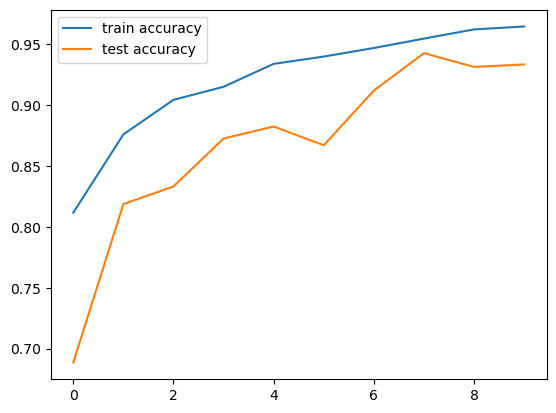

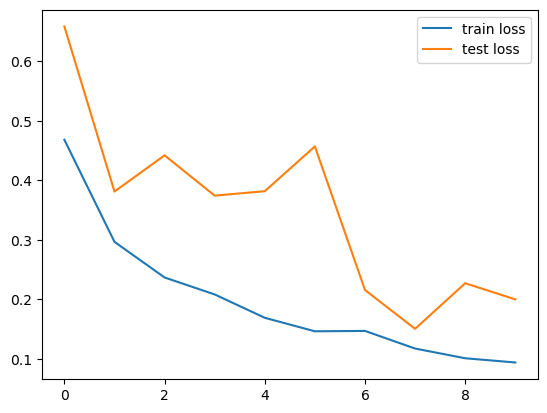

In [47]:
# Plotting training history (accuracy and loss)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='test accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='test loss')
plt.legend()
plt.show()

In [49]:
# Example: Predict on a test image
sample_image = x_test[0]  # Taking the first image from the test set
sample_image = np.expand_dims(sample_image, axis=0)  # Add batch dimension
prediction = loaded_model.predict(sample_image)
print("Prediction:", "COVID" if prediction[0] > 0.5 else "Normal")

# Example: Predict and display first few test predictions
predictions = loaded_model.predict(x_test)
for i in range(10):
    print(f"Predicted: {'COVID' if predictions[i] > 0.5 else 'Normal'}, Actual: {'COVID' if y_test[i] == 1 else 'Normal'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Prediction: Normal
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step
Predicted: Normal, Actual: Normal
Predicted: Normal, Actual: Normal
Predicted: Normal, Actual: Normal
Predicted: COVID, Actual: COVID
Predicted: COVID, Actual: COVID
Predicted: Normal, Actual: Normal
Predicted: Normal, Actual: Normal
Predicted: Normal, Actual: Normal
Predicted: Normal, Actual: Normal
Predicted: Normal, Actual: Normal


108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step


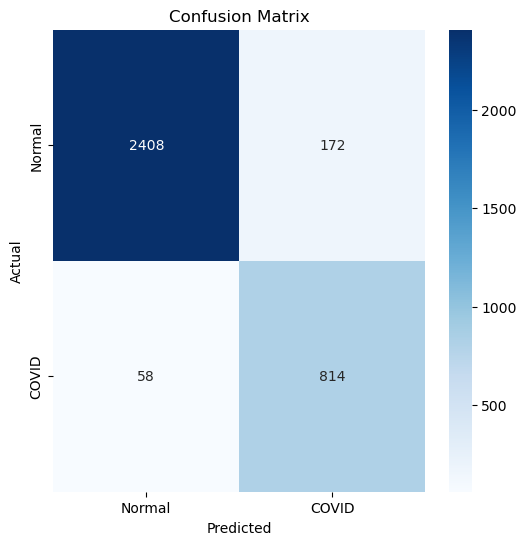

In [55]:

# Predict on test data
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5)  # Convert probabilities to binary class labels

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'COVID'], yticklabels=['Normal', 'COVID'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


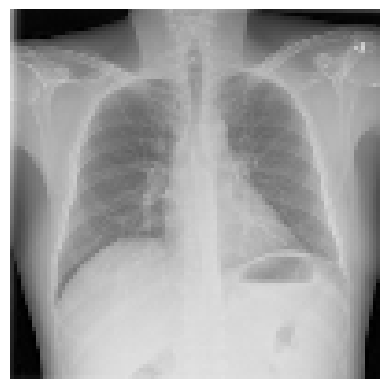

Predicted: Normal


In [77]:
import json
from tensorflow.keras.models import model_from_json
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the model architecture from the JSON file
json_path = r"C:\Users\ayush\Desktop\Bugs\model_architecture.json"
with open(json_path, 'r') as json_file:
    model_json = json_file.read()

# Create the model from the JSON architecture
model = model_from_json(model_json)

# Load the model weights from the .h5 file
weights_path = r"C:\Users\ayush\Desktop\Bugs\model_weights.weights.h5"
model.load_weights(weights_path)

# Load and preprocess the image
image_path = r"C:\Users\ayush\Downloads\Normal-3.png"
img = cv2.imread(image_path)

# Resize the image to match the input shape of the model (100x100)
img_resized = cv2.resize(img, (100, 100))

# Normalize the image (the model expects pixel values between 0 and 1)
img_normalized = img_resized / 255.0

# Add a batch dimension (the model expects a batch of images, even for a single image)
img_input = np.expand_dims(img_normalized, axis=0)

# Make a prediction
prediction = model.predict(img_input)

# Display the input image
plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Hide axes
plt.show()

# Output the prediction
if prediction[0] > 0.5:
    print("Predicted: COVID")
else:
    print("Predicted: Normal")
